# Visión por computadora

## TP 1 

Tomás Abraham

A2602

## Parte 1

In [1]:
import numpy as np #
import cv2 as cv
import matplotlib.pyplot as plt

Imágenes en /white_patch:

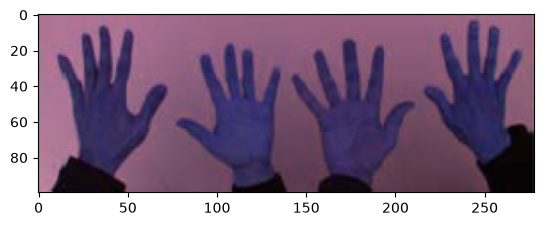

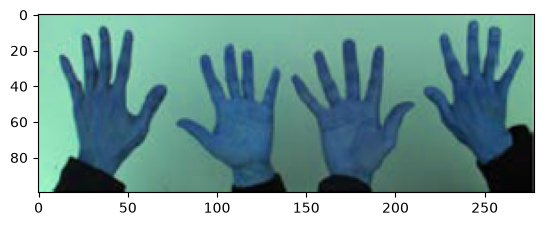

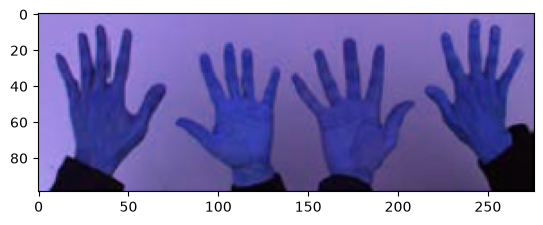

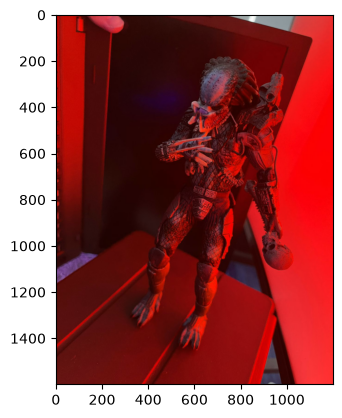

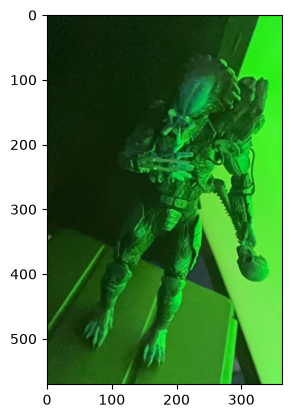

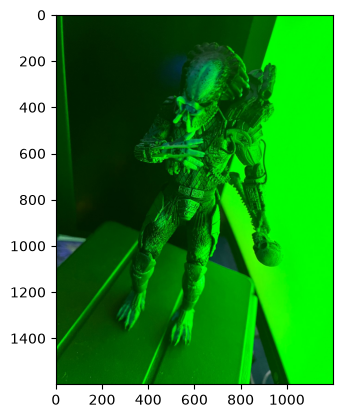

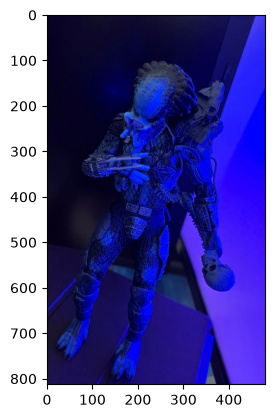

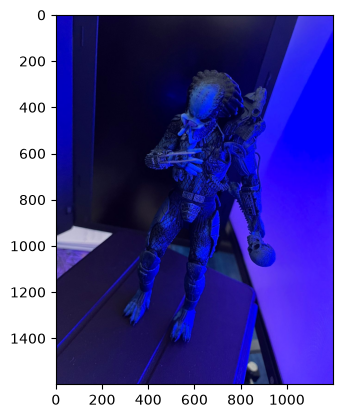

In [2]:
imgs = [cv.imread('white_patch/test_blue.png'),
        cv.imread('white_patch/test_green.png'),
        cv.imread('white_patch/test_red.png'),
        cv.imread('white_patch/wp_blue.jpg'),
        cv.imread('white_patch/wp_green.png'),
        cv.imread('white_patch/wp_green2.jpg'),
        cv.imread('white_patch/wp_red.png'),
        cv.imread('white_patch/wp_red2.jpg'),
       ]

for img in imgs:
    # Muestro la imagen con matplotlib
    plt.figure()
    plt.imshow(img)
    plt.show()

Las imagenes se ven raras, las manos se ven azules.
Esto sucede porque openCV carga las imagenes en BGR, y matplotlib lee en RGB. Voy a invertir los canales

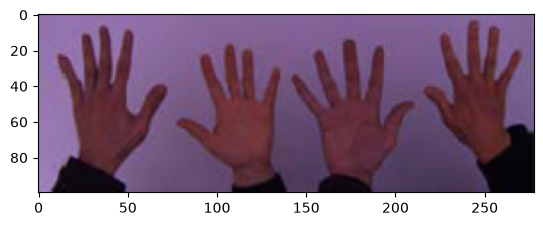

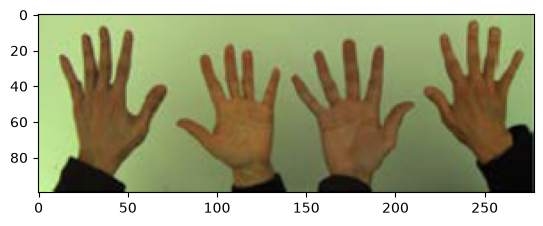

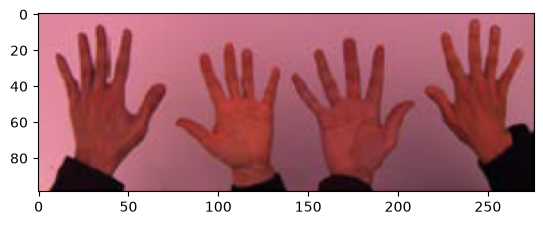

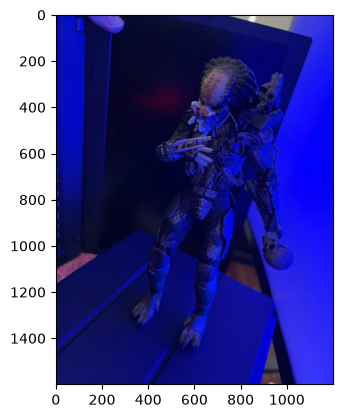

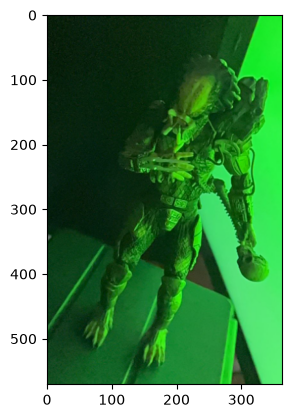

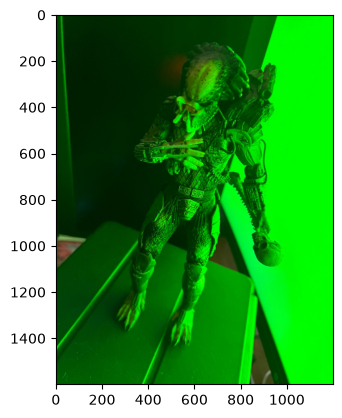

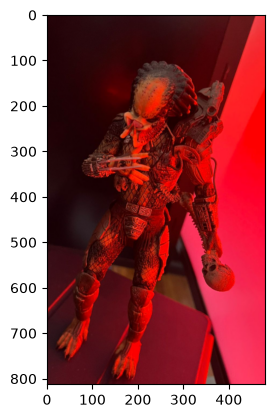

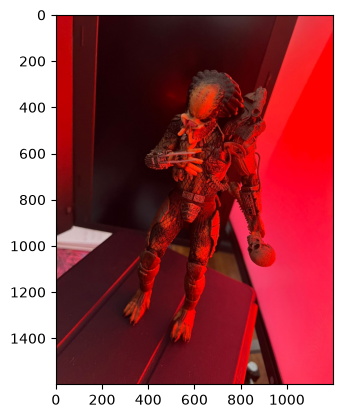

In [3]:
imgsRGB = []

for img in imgs:

    imgsRGB.append( cv.cvtColor(img, cv.COLOR_BGR2RGB) )

for img in imgsRGB:
    # Muestro la imagen con matplotlib
    plt.figure()
    plt.imshow(img)
    plt.show()



Las imágenes ya se ven mejor ahora.

Implemento el algoritmo White Patch:

In [4]:
def white_patch(img):
    
    # Convierto la imagen a flot para evitar truncamiento en la división
    img_float = img.astype(np.float32)
    
    # tomo cada canal por separado
    canalB = img_float[:, :, 0]
    canalG = img_float[:, :, 1]
    canalR = img_float[:, :, 2]

    # Obtener el máximo de cada canal
    Bmax = np.max(canalB)
    Gmax = np.max(canalG)
    Rmax = np.max(canalR)

    # para evitar división por 0 y no modificar el canal en caso de que sea 0 (canal vacío)
    Bmax = 255.0 if Bmax == 0 else Bmax
    Gmax = 255.0 if Gmax == 0 else Gmax
    Rmax = 255.0 if Rmax == 0 else Rmax

    # Normalizo cada canal por separado
    canalB = (255.0 / Bmax) * canalB
    canalG = (255.0 / Gmax) * canalG
    canalR = (255.0 / Rmax) * canalR

    # Vuelvo a armar la imagen
    img_corregida = np.stack([canalB, canalG, canalR], axis=2)
    img_corregida = np.clip(img_corregida, 0, 255)

    # Devolver como imagen entera de 8 bits
    return img_corregida.astype(np.uint8)
    
    

In [5]:
imgsWhitePatch = []

for img in imgsRGB:

    imgsWhitePatch.append(white_patch(img))


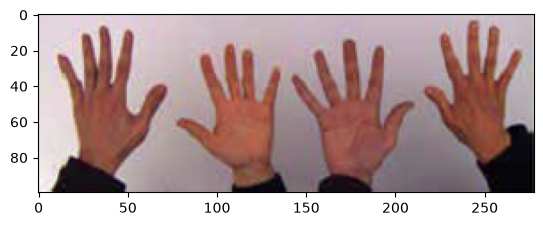

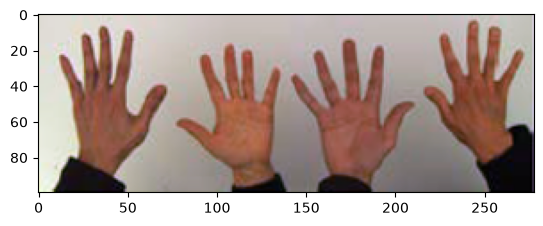

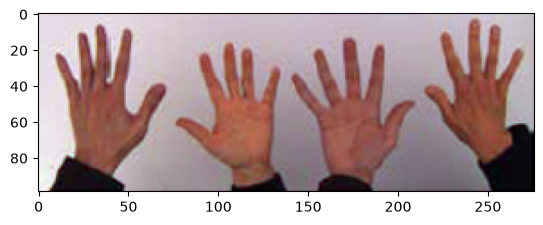

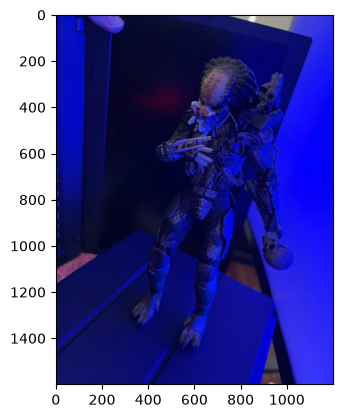

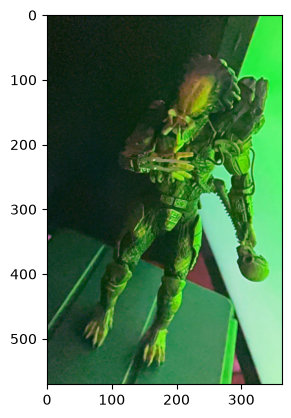

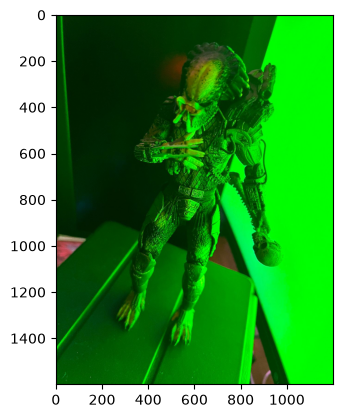

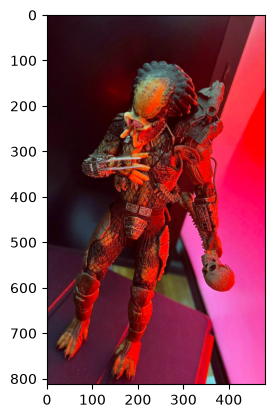

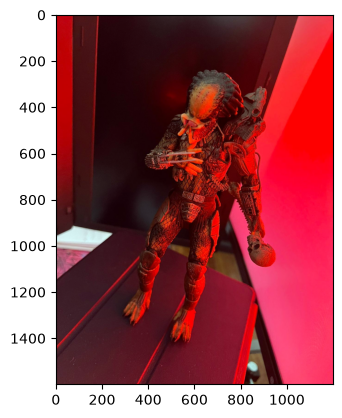

In [6]:
for img in imgsWhitePatch:

    plt.figure()
    plt.imshow(img)
    plt.show()

### Muestro las imagenes de a pares para poder analizar mejor:

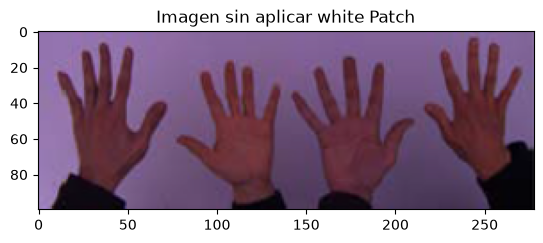

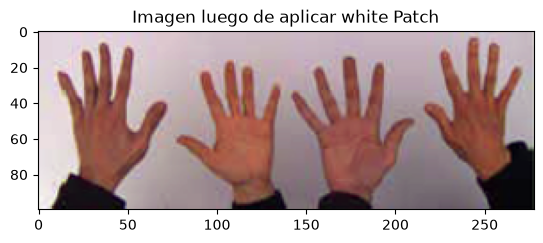

In [7]:
    plt.figure()
    plt.imshow(imgsRGB[0])
    plt.title("Imagen sin aplicar white Patch")
    plt.show()

    plt.figure()
    plt.title("Imagen luego de aplicar white Patch")
    plt.imshow(imgsWhitePatch[0])
    plt.show()

En este par de imagenes se puede observar que la imagen original parece iluminada con color azul, y en consecuencia las manos oscurecidas se ven oscurecidas. Al aplicar un algoritmo de White Patch se logra que las componentes de los canales con menor intensidad se normalicen y se equiparen al brillo de los canales con más intensidad. Por eso mejora considerablemente la calidad de la imagen.

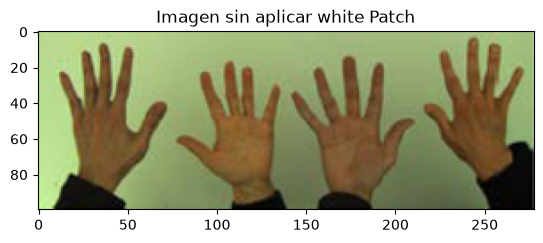

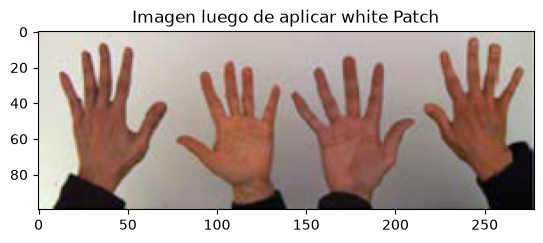

In [8]:
i = 1

plt.figure()
plt.imshow(imgsRGB[i])
plt.title("Imagen sin aplicar white Patch")
plt.show()

plt.figure()
plt.title("Imagen luego de aplicar white Patch")
plt.imshow(imgsWhitePatch[i])
plt.show()

Sucede lo mismo que en la imagen anterior, pero parece que en este caso estaba iluminada con luz verde.

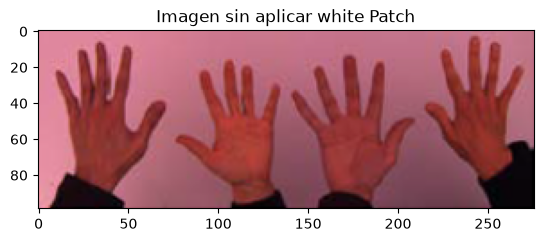

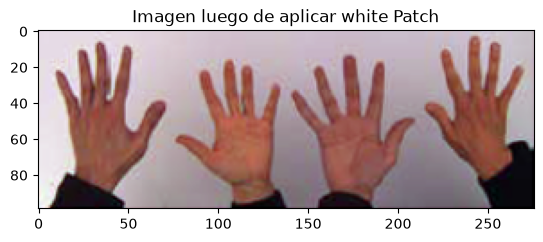

In [9]:
i =  i + 1

plt.figure()
plt.imshow(imgsRGB[i])
plt.title("Imagen sin aplicar white Patch")
plt.show()

plt.figure()
plt.title("Imagen luego de aplicar white Patch")
plt.imshow(imgsWhitePatch[i])
plt.show()

Sucede lo mismo que en las imagenes anteriores pero en este caso la imagen estaba iluminada con luz roja.

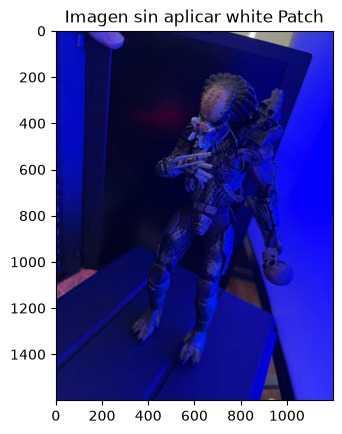

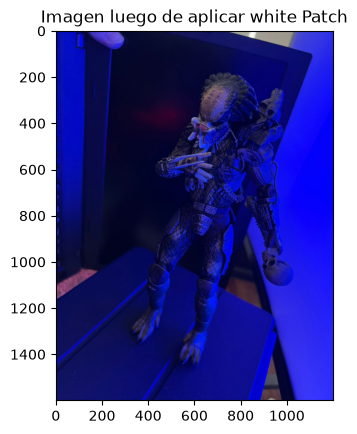

In [10]:
i =  i + 1

plt.figure()
plt.imshow(imgsRGB[i])
plt.title("Imagen sin aplicar white Patch")
plt.show()

plt.figure()
plt.title("Imagen luego de aplicar white Patch")
plt.imshow(imgsWhitePatch[i])
plt.show()

Esta imagen parece no haber percibido cambios luego de aplicar el algoritmo white patch. Vamos a intentar explicar esto extryendo los valores máximos de cada canal en la imagen original. Si los valores son cercanos a 255, el valor del pixel en la función white patch se va a multiplicar por 1, por lo tanto no sufre cambios.

In [14]:
canalR = imgs[i][:, :, 0]
canalG = imgs[i][:, :, 1]
canalB = imgs[i][:, :, 2]

print("Valor maximo del canal rojo: ", np.max(canalR))
print("Valor maximo del canal verde: ", np.max(canalG))
print("Valor maximo del canal azul: ", np.max(canalB))



Valor maximo del canal rojo:  255
Valor maximo del canal verde:  255
Valor maximo del canal azul:  255


Estos valores explican el no haber percibido cambios entre las imagenes.

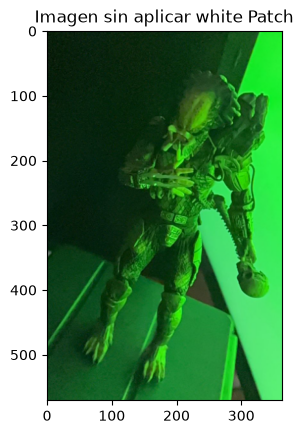

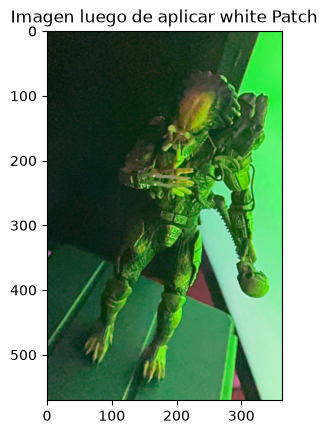

In [15]:
i =  i + 1

plt.figure()
plt.imshow(imgsRGB[i])
plt.title("Imagen sin aplicar white Patch")
plt.show()

plt.figure()
plt.title("Imagen luego de aplicar white Patch")
plt.imshow(imgsWhitePatch[i])
plt.show()

En este caso se ve que la imagen original tenía mucha influencia del color verde, en la imagen luego de aplicar el algoritmo parecen verse otros colores. 

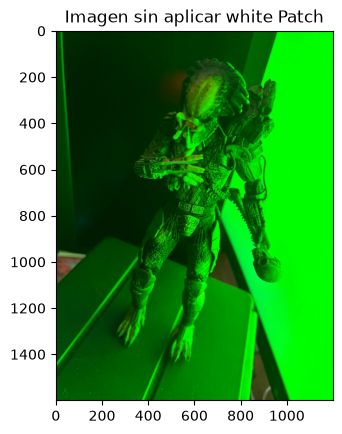

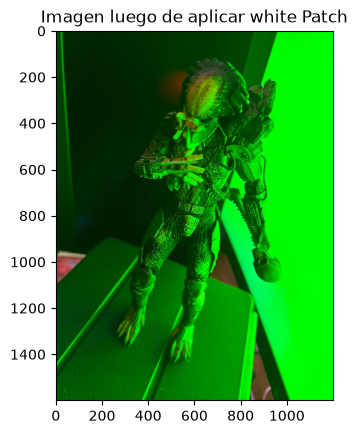

In [16]:
i =  i + 1

plt.figure()
plt.imshow(imgsRGB[i])
plt.title("Imagen sin aplicar white Patch")
plt.show()

plt.figure()
plt.title("Imagen luego de aplicar white Patch")
plt.imshow(imgsWhitePatch[i])
plt.show()

En este caso cambia un poco la imagen respecto de la anterior porque una es forrmato '.png' y la otra '.jpg', esto puede modificar el resultado final ya que la compresión de las imagenes es distinta y en el caso del JPG puede generar máximos falsos por la compresión. Si genera máximos falsos de un color, quiere decir que el algoritmo white patch tendrá menos efecto.

Lo mismo sucede en las imagenes siguientes

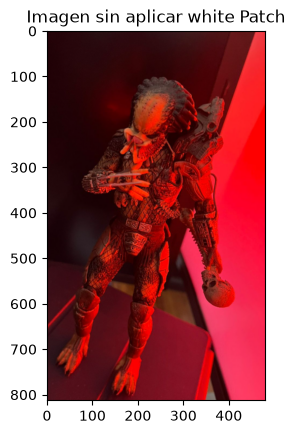

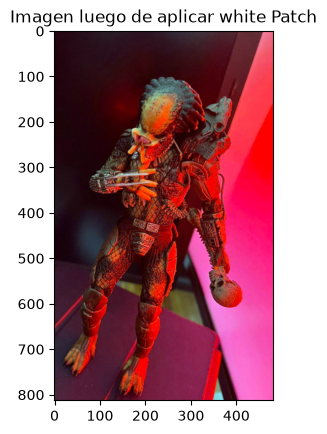

In [17]:
i =  i + 1

plt.figure()
plt.imshow(imgsRGB[i])
plt.title("Imagen sin aplicar white Patch")
plt.show()

plt.figure()
plt.title("Imagen luego de aplicar white Patch")
plt.imshow(imgsWhitePatch[i])
plt.show()

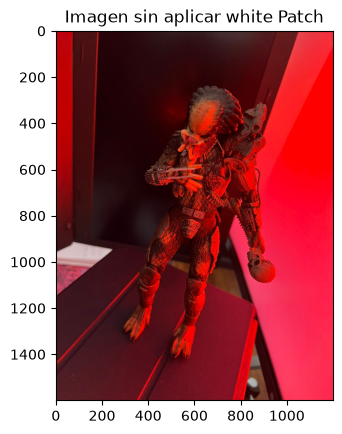

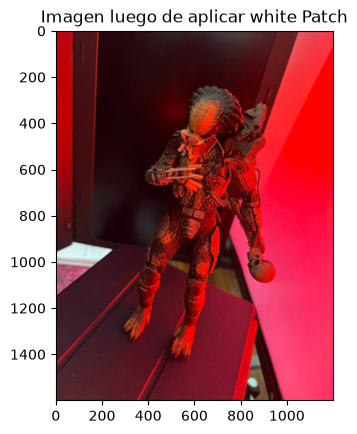

In [18]:
i =  i + 1

plt.figure()
plt.imshow(imgsRGB[i])
plt.title("Imagen sin aplicar white Patch")
plt.show()

plt.figure()
plt.title("Imagen luego de aplicar white Patch")
plt.imshow(imgsWhitePatch[i])
plt.show()

## Parte 2

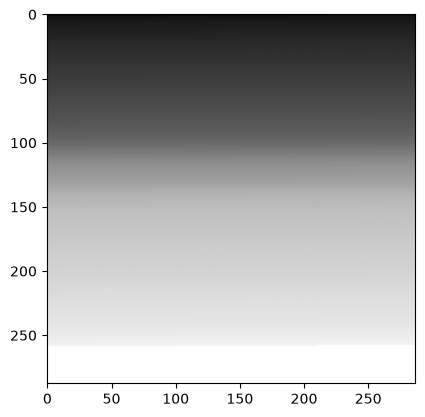

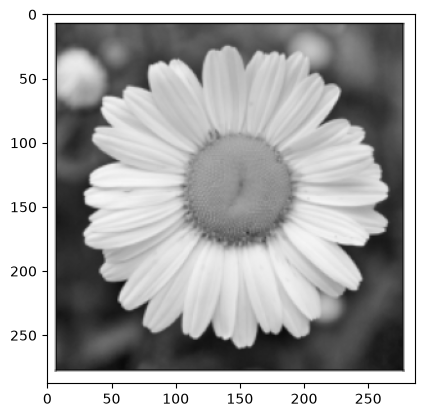

In [32]:
imgsParte2 = [cv.imread('img1_tp.png', cv.IMREAD_GRAYSCALE),
              cv.imread('img2_tp.png', cv.IMREAD_GRAYSCALE),
             ]

plt.figure()
plt.imshow(imgsParte2[0], cmap='gray')
plt.show()

plt.figure()
plt.imshow(imgsParte2[1], cmap='gray')
plt.show()

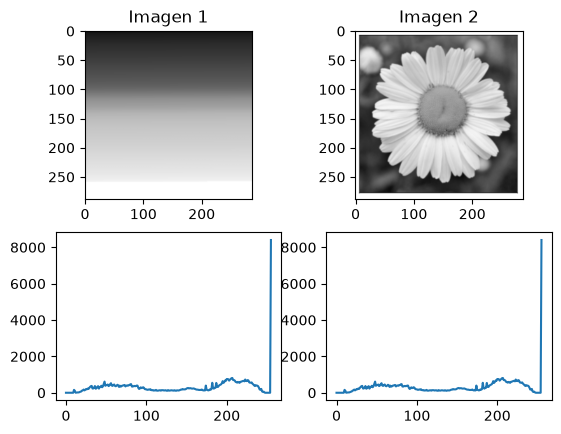

In [36]:
# Nueva figura
fig = plt.figure()

# Imagen original
ax1=plt.subplot(221)
ax1.imshow(imgsParte2[0], cmap='gray', vmin=0, vmax=255)
ax1.set_title('Imagen 1')

hist1,bins1 = np.histogram(imgsParte2[0].ravel(),256,[0,256])
ax3=plt.subplot(223)
ax3.plot(hist1)

ax2=plt.subplot(222)
ax2.imshow(imgsParte2[1], cmap='gray', vmin=0, vmax=255)
ax2.set_title('Imagen 2')

hist2,bins2 = np.histogram(imgsParte2[1].ravel(),256,[0,256])
ax4=plt.subplot(224)
ax4.plot(hist2)

plt.show()


A simple vista parecería que los histogramas deberían dar totalmente distintos, a priori yo creí que iba a ver un histograma prácticamente constante en el caso de la imagen 1 y un histograma como el obtenido en la imagen 2.

Evidentemente la imagen 1 está hecha para que, intencionalmente, se obtenga un histograma casi idéntico al de la imagen 2.

Lo que me lleva a responder que el histograma, al menos en una aplicación como esta, no sería un buen dato para entrenar un modelo de imágenes. Ya que si, por ejemplo, estuviéramos entrenando un modelo que detecte si la imagen es una flor, tranquilamente podría dar un TRUE en ambas imagenes produciendo un error. En este caso puede ser engañoso, de hecho revisé el código varias veces intentando ver dónde había graficado dos veces el mismo histograma (buen bait).

Sin embargo no descarto que el histograma pueda ser una varias entradas de un modelo y pueda aportar algo, siempre depende del contexto y de la aplicación. Habría que hacer un amálisis de datos en un dataset concreto y quizás se pueda llegar a sacar alguna conclusión más elaborada.

PD: el número de bins utilizado fue 256, para poder visualizar la ocurrencia de cada intensidad en particular.